In [1]:
#Imports
import os
import matplotlib.pyplot as plt
from DescriptionLookup import DescriptionLookup

from contexts import Plasmid
from contexts import GenomeRegion
from contexts import make_mcs_insert_fn
from contexts import infer_table18_primer_tails
from contexts import reverse_complement

from CAGI5_bench import CAGI5_bench
from typing import Callable, Dict, Any

os.environ['GENALM_HOME'] = '/workspace-SR003.nfs2/estsoi/CAGI5_benchmark'
os.environ['PYTHONPATH'] += '/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction'

/home/jovyan/miniconda3/envs/cagi5/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
plasmid = Plasmid('https://www.ncbi.nlm.nih.gov/nuccore/MK484103.1', 
                    data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', 
                    reporter_feature_name='similar to firefly luciferase; synthetic luc2 version of the luciferase gene')

tails = infer_table18_primer_tails('/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa', flank=200, min_match=15)

plasmid_context_NO_AUG = plasmid.plasmid_context(primer_tails = tails, context_size=None, circular=True)
lookup = DescriptionLookup(json_dir='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/descriptions', keys=['HEK293T', 'HEL92.1.7', 'HaCaT', 'HeLa', 'HepG2', 'K562', 'LNCaP','MIN6', 'NIH-3T3', 'Neuro-2a', 'SF7996', 'SK-MEL-28'])
bench = CAGI5_bench(model_cls='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/expression_model_final.py::ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=100,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup,
            device='cuda:0')
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom', 
                            context_fn=plasmid_context_NO_AUG)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:158: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

  0%|          | 0/18468 [00:00<?, ?it/s]Casting fp32 inputs back to torch.float16 for flash-attn compatibility.


In [18]:
def _find_all(sequence: str, needle: str) -> list[int]:
    starts: list[int] = []
    start = 0
    while True:
        index = sequence.find(needle, start)
        if index == -1:
            return starts
        starts.append(index)
        start = index + 1
def run_context_function_tests(
    mpra_fragment: str,
    *,
    element: str | None = None,
    plasmid_context: Callable[..., str] | None = None,
    genome_context: Callable[[str], str] | None = None,
    plasmid: Plasmid | None = None,
    expected_length: int | None = None,
    tss_sequence: str | None = None,
    expected_tss_index: int | None = None,
    middle_tolerance: int = 100,
    tss_tolerance: int = 500,
    tss_anchor_length: int = 40,
    strict: bool = True,
) -> Dict[str, Any]:
    """
    Run diagnostics for MPRA context functions and print exact construct locations.

    Typical calls:
        run_context_function_tests(
            mpra_fragment,
            element="F9-24h",
            plasmid_context=plasmid_context_AUG,
            plasmid=plasmid,
            expected_length=20_000,
        )

        run_context_function_tests(
            mpra_fragment,
            element="F9-24h",
            plasmid_context=plasmid_context_AUG,
            genome_context=genome_context,
            plasmid=plasmid,
            expected_length=20_000,
        )

    The function returns a diagnostics dictionary. With `strict=True`, failed
    checks raise AssertionError after all diagnostics have been printed.
    """
    if plasmid_context is None and genome_context is None:
        raise ValueError("Provide plasmid_context, genome_context, or both")
    if plasmid_context is not None and element is None:
        raise ValueError("Provide element when testing a plasmid_context callable")
    if expected_length is not None and expected_length <= 0:
        raise ValueError("expected_length must be positive")
    if middle_tolerance < 0 or tss_tolerance < 0:
        raise ValueError("Tolerances must be non-negative")

    mpra = GenomeRegion._clean_sequence(mpra_fragment)
    plasmid_construct: str | None = None

    if plasmid_context is not None:
        plasmid_construct = plasmid_context(mpra, element)
        construct = plasmid_construct
    else:
        construct = mpra

    sequence_inserted_into_genome = construct
    if genome_context is not None:
        construct = genome_context(sequence_inserted_into_genome)

    construct = GenomeRegion._clean_sequence(construct)
    construct_middle = len(construct) // 2
    mpra_starts = _find_all(construct, mpra)

    checks: list[Tuple[str, bool, str]] = []
    diagnostics: Dict[str, Any] = {
        "construct_length": len(construct),
        "expected_length": expected_length,
        "construct_middle": construct_middle,
        "mpra_length": len(mpra),
        "mpra_occurrences": len(mpra_starts),
        "mpra_starts": mpra_starts,
        "mpra_ends": [start + len(mpra) for start in mpra_starts],
        "plasmid_construct_length": len(plasmid_construct) if plasmid_construct is not None else None,
        "vector_length": len(plasmid_construct) - len(mpra) if plasmid_construct is not None else None,
        "genome_flank_length": (
            len(construct) - len(sequence_inserted_into_genome)
            if genome_context is not None
            else None
        ),
    }

    if expected_length is not None:
        checks.append(
            (
                "construct length",
                len(construct) == expected_length,
                f"observed {len(construct)}, expected {expected_length}",
            )
        )

    checks.append(
        (
            "MPRA fragment occurs once",
            len(mpra_starts) == 1,
            f"observed {len(mpra_starts)} occurrence(s)",
        )
    )

    if mpra_starts:
        mpra_start = mpra_starts[0]
        mpra_end = mpra_start + len(mpra)
        mpra_center = (mpra_start + mpra_end) // 2
        diagnostics.update(
            {
                "mpra_start": mpra_start,
                "mpra_end": mpra_end,
                "mpra_center": mpra_center,
                "mpra_distance_from_middle": mpra_center - construct_middle,
            }
        )
        checks.append(
            (
                "MPRA insertion near middle",
                abs(mpra_center - construct_middle) <= middle_tolerance,
                (
                    f"MPRA center {mpra_center}, expected near {construct_middle} "
                    f"+/- {middle_tolerance}"
                ),
            )
        )

    tss_starts: list[int] = []
    tss_label = None
    if expected_tss_index is not None:
        tss_starts = [expected_tss_index]
        tss_label = "expected_tss_index"
    elif tss_sequence is not None:
        tss_marker = GenomeRegion._clean_sequence(tss_sequence)
        tss_starts = _find_all(construct, tss_marker)
        tss_label = "tss_sequence"
    elif plasmid is not None:
        old_tss = plasmid.reporter_tss_index()
        tss_marker = plasmid.sequence[old_tss : old_tss + tss_anchor_length].upper()
        if len(tss_marker) < tss_anchor_length:
            raise ValueError("Plasmid TSS anchor is shorter than tss_anchor_length")
        tss_starts = _find_all(construct, tss_marker)
        tss_label = f"plasmid reporter TSS anchor ({tss_anchor_length} bp)"

    diagnostics["tss_label"] = tss_label
    diagnostics["tss_starts"] = tss_starts
    diagnostics["tss_occurrences"] = len(tss_starts)

    if tss_label is not None:
        checks.append(
            (
                "TSS marker occurs once",
                len(tss_starts) == 1,
                f"observed {len(tss_starts)} occurrence(s) for {tss_label}",
            )
        )
        if tss_starts:
            tss_index = tss_starts[0]
            diagnostics["tss_index"] = tss_index
            diagnostics["tss_distance_from_middle"] = tss_index - construct_middle
            checks.append(
                (
                    "TSS near middle",
                    abs(tss_index - construct_middle) <= middle_tolerance,
                    (
                        f"TSS index {tss_index}, expected near {construct_middle} "
                        f"+/- {middle_tolerance}"
                    ),
                )
            )
            if mpra_starts:
                mpra_center = diagnostics["mpra_center"]
                diagnostics["mpra_center_distance_from_tss"] = mpra_center - tss_index
                checks.append(
                    (
                        "MPRA insertion near TSS",
                        abs(mpra_center - tss_index) <= tss_tolerance,
                        (
                            f"MPRA center {mpra_center}, TSS index {tss_index}, "
                            f"allowed distance +/- {tss_tolerance}"
                        ),
                    )
                )

    invalid = sorted(set(construct) - set("ACGTN"))
    checks.append(("DNA alphabet only", not invalid, f"invalid symbols: {''.join(invalid) or 'none'}"))
    checks.append(("no whitespace", not any(base.isspace() for base in construct), "construct has no whitespace"))
    checks.append(("uppercase output", construct == construct.upper(), "construct is uppercase"))

    if genome_context is not None:
        genome_insert_starts = _find_all(construct, sequence_inserted_into_genome)
        diagnostics["genome_insert_starts"] = genome_insert_starts
        checks.append(
            (
                "sequence inserted into genome occurs once",
                len(genome_insert_starts) == 1,
                f"observed {len(genome_insert_starts)} occurrence(s)",
            )
        )
        if genome_insert_starts:
            left_len = genome_insert_starts[0]
            right_len = len(construct) - left_len - len(sequence_inserted_into_genome)
            diagnostics["left_genome_flank_length"] = left_len
            diagnostics["right_genome_flank_length"] = right_len
            checks.append(
                (
                    "genomic flanks are balanced",
                    abs(left_len - right_len) <= 1,
                    f"left flank {left_len}, right flank {right_len}",
                )
            )

    rc_mpra = reverse_complement(mpra)
    if rc_mpra != mpra:
        rc_starts = _find_all(construct, rc_mpra)
        diagnostics["reverse_complement_mpra_occurrences"] = len(rc_starts)
        diagnostics["reverse_complement_mpra_starts"] = rc_starts
        checks.append(
            (
                "reverse-complement MPRA not duplicated",
                len(rc_starts) == 0,
                f"observed {len(rc_starts)} reverse-complement occurrence(s)",
            )
        )

    diagnostics["checks"] = [
        {"name": name, "passed": passed, "detail": detail}
        for name, passed, detail in checks
    ]

    print("=== MPRA context diagnostics ===")
    print(f"construct length: {len(construct)}")
    if expected_length is not None:
        print(f"expected length: {expected_length}")
    print(f"expected middle near index: {construct_middle} (+/- {middle_tolerance})")
    print(f"part lengths: MPRA={len(mpra)}")
    if plasmid_construct is not None:
        print(
            "part lengths: "
            f"plasmid_construct={len(plasmid_construct)}, "
            f"vector_without_mpra={len(plasmid_construct) - len(mpra)}"
        )
    if genome_context is not None:
        print(f"part lengths: genome_flanks_total={len(construct) - len(sequence_inserted_into_genome)}")

    if mpra_starts:
        print(
            "MPRA exact location: "
            f"start={diagnostics['mpra_start']}, end={diagnostics['mpra_end']}, "
            f"center={diagnostics['mpra_center']}"
        )
    else:
        print("MPRA exact location: not found")

    if tss_label is None:
        print("TSS exact location: not checked; pass plasmid, tss_sequence, or expected_tss_index")
    elif tss_starts:
        print(f"TSS exact location ({tss_label}): index={tss_starts[0]}")
    else:
        print(f"TSS exact location ({tss_label}): not found")

    failed = []
    for name, passed, detail in checks:
        status = "PASS" if passed else "FAIL"
        print(f"{status}: {name} - {detail}")
        if not passed:
            failed.append(f"{name}: {detail}")

    if strict and failed:
        raise AssertionError("MPRA context checks failed:\n" + "\n".join(failed))

    return diagnostics

**Correlation plotting function**

In [2]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_correlations(corr_dict, figsize=(10, 4), sort=False, ax=None, title = 'Correlation by element | all cell types'):
    """
    Plot off-diagonal correlation value for each 2x2 tensor in corr_dict.

    corr_dict: dict[str, torch.Tensor]
        Example: {"F9": tensor([[1, r], [r, 1]], device="cuda")}
    """

    rows = []

    for name, mat in corr_dict.items():
        mat = mat.detach().float().cpu()

        if mat.shape != (2, 2):
            raise ValueError(f"{name} has shape {mat.shape}, expected (2, 2)")

        # Average both off-diagonal values in case fp16 makes them slightly different
        corr = ((mat[0, 1] + mat[1, 0]) / 2).item()
        rows.append({"name": name, "correlation": corr})

    df = pd.DataFrame(rows).sort_values(by='correlation', ascending=False)

    if sort:
        df = df.sort_values("correlation")

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=df,
        x="name",
        y="correlation",
        ax=ax,
        color="steelblue",
    )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("")
    ax.set_ylabel("Correlation")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_ylim(
        min(-0.05, df["correlation"].min() - 0.05),
        max(0.05, df["correlation"].max() + 0.05),
    )

    plt.tight_layout()
    plt.title(title)
    return ax, df

**Loading descriptions**

In [2]:
#GENERATED
lookup = DescriptionLookup(json_dir='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/descriptions', keys=['HEK293T', 'HEL92.1.7', 'HaCaT', 'HeLa', 'HepG2', 'K562', 'LNCaP','MIN6', 'NIH-3T3', 'Neuro-2a', 'SF7996', 'SK-MEL-28'])
#REAL
#lookup = DescriptionLookup(json_dir='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/metadata', keys=['HEK293T', 'HEL92.1.7', 'HaCaT', 'HeLa', 'HepG2', 'K562', 'LNCaP','MIN6', 'NIH-3T3', 'Neuro-2a', 'SF7996', 'SK-MEL-28'])

**Contexts initialization**

In [5]:
plasmid = Plasmid('https://www.ncbi.nlm.nih.gov/nuccore/MK484103.1', 
                    data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', 
                    reporter_feature_name='similar to firefly luciferase; synthetic luc2 version of the luciferase gene')

tails = infer_table18_primer_tails('/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa', flank=200, min_match=15)

plasmid_context_NO_AUG = plasmid.plasmid_context(primer_tails = tails, context_size=None, circular=True)

plasmid_context_AUG = plasmid.plasmid_context(primer_tails = tails, context_size=20_000, circular=True)

In [6]:
genome = GenomeRegion(genome_path='/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa')
genome_context = genome.genomic_context(region='AAVS1', target_length=20_000)

In [32]:
run_context_function_tests(
    'AAAAAAAAAAAAAAAAAAAAAAAAAAGGGGGGGGGGGGGAAAAAAAAAAAAAAAAAAAAAAAAAAA',
    element="LDLR",
    plasmid_context=plasmid_context_AUG,
    plasmid=plasmid,
    expected_length=20_000,
    strict=False
)

=== MPRA context diagnostics ===
construct length: 20000
expected length: 20000
expected middle near index: 10000 (+/- 100)
part lengths: MPRA=66
part lengths: plasmid_construct=20000, vector_without_mpra=19934
MPRA exact location: start=9899, end=9965, center=9932
TSS exact location (plasmid reporter TSS anchor (40 bp)): index=1256
PASS: construct length - observed 20000, expected 20000
PASS: MPRA fragment occurs once - observed 1 occurrence(s)
PASS: MPRA insertion near middle - MPRA center 9932, expected near 10000 +/- 100
FAIL: TSS marker occurs once - observed 5 occurrence(s) for plasmid reporter TSS anchor (40 bp)
FAIL: TSS near middle - TSS index 1256, expected near 10000 +/- 100
FAIL: MPRA insertion near TSS - MPRA center 9932, TSS index 1256, allowed distance +/- 500
PASS: DNA alphabet only - invalid symbols: none
PASS: no whitespace - construct has no whitespace
PASS: uppercase output - construct is uppercase
PASS: reverse-complement MPRA not duplicated - observed 0 reverse-co

{'construct_length': 20000,
 'expected_length': 20000,
 'construct_middle': 10000,
 'mpra_length': 66,
 'mpra_occurrences': 1,
 'mpra_starts': [9899],
 'mpra_ends': [9965],
 'plasmid_construct_length': 20000,
 'vector_length': 19934,
 'genome_flank_length': None,
 'mpra_start': 9899,
 'mpra_end': 9965,
 'mpra_center': 9932,
 'mpra_distance_from_middle': -68,
 'tss_label': 'plasmid reporter TSS anchor (40 bp)',
 'tss_starts': [1256, 5628, 10000, 14372, 18744],
 'tss_occurrences': 5,
 'tss_index': 1256,
 'tss_distance_from_middle': -8744,
 'mpra_center_distance_from_tss': 8676,
 'reverse_complement_mpra_occurrences': 0,
 'reverse_complement_mpra_starts': [],
 'checks': [{'name': 'construct length',
   'passed': True,
   'detail': 'observed 20000, expected 20000'},
  {'name': 'MPRA fragment occurs once',
   'passed': True,
   'detail': 'observed 1 occurrence(s)'},
  {'name': 'MPRA insertion near middle',
   'passed': True,
   'detail': 'MPRA center 9932, expected near 10000 +/- 100'},
  {

In [25]:
run_context_function_tests(
    'AAAAAAAAAAAAAAAAAAAAAAAAAAGGGGGGGGGGGGGAAAAAAAAAAAAAAAAAAAAAAAAAAA',
    element="LDLR",
    plasmid_context=plasmid_context_NO_AUG,
    genome_context=genome_context,
    plasmid=plasmid,
    expected_length=20_000,
)

=== MPRA context diagnostics ===
construct length: 20000
expected length: 20000
expected middle near index: 10000 (+/- 100)
part lengths: MPRA=66
part lengths: plasmid_construct=4427, vector_without_mpra=4361
part lengths: genome_flanks_total=15573
MPRA exact location: start=9898, end=9964, center=9931
TSS exact location (plasmid reporter TSS anchor (40 bp)): index=9999
PASS: construct length - observed 20000, expected 20000
PASS: MPRA fragment occurs once - observed 1 occurrence(s)
PASS: MPRA insertion near middle - MPRA center 9931, expected near 10000 +/- 100
PASS: TSS marker occurs once - observed 1 occurrence(s) for plasmid reporter TSS anchor (40 bp)
PASS: TSS near middle - TSS index 9999, expected near 10000 +/- 100
PASS: MPRA insertion near TSS - MPRA center 9931, TSS index 9999, allowed distance +/- 500
PASS: DNA alphabet only - invalid symbols: none
PASS: no whitespace - construct has no whitespace
PASS: uppercase output - construct is uppercase
PASS: sequence inserted into g

{'construct_length': 20000,
 'expected_length': 20000,
 'construct_middle': 10000,
 'mpra_length': 66,
 'mpra_occurrences': 1,
 'mpra_starts': [9898],
 'mpra_ends': [9964],
 'plasmid_construct_length': 4427,
 'vector_length': 4361,
 'genome_flank_length': 15573,
 'mpra_start': 9898,
 'mpra_end': 9964,
 'mpra_center': 9931,
 'mpra_distance_from_middle': -69,
 'tss_label': 'plasmid reporter TSS anchor (40 bp)',
 'tss_starts': [9999],
 'tss_occurrences': 1,
 'tss_index': 9999,
 'tss_distance_from_middle': -1,
 'mpra_center_distance_from_tss': -68,
 'genome_insert_starts': [7786],
 'left_genome_flank_length': 7786,
 'right_genome_flank_length': 7787,
 'reverse_complement_mpra_occurrences': 0,
 'reverse_complement_mpra_starts': [],
 'checks': [{'name': 'construct length',
   'passed': True,
   'detail': 'observed 20000, expected 20000'},
  {'name': 'MPRA fragment occurs once',
   'passed': True,
   'detail': 'observed 1 occurrence(s)'},
  {'name': 'MPRA insertion near middle',
   'passed': 

In [27]:
run_context_function_tests(
    'AAAAAAAAAAAAAAAAAAAAAAAAAAGGGGGGGGGGGGGAAAAAAAAAAAAAAAAAAAAAAAAAAA',
    element="LDLR",
    genome_context=genome_context,
    plasmid=plasmid,
    expected_length=20_000,
    strict=False
)

=== MPRA context diagnostics ===
construct length: 20000
expected length: 20000
expected middle near index: 10000 (+/- 100)
part lengths: MPRA=66
part lengths: genome_flanks_total=19934
MPRA exact location: start=9967, end=10033, center=10000
TSS exact location (plasmid reporter TSS anchor (40 bp)): not found
PASS: construct length - observed 20000, expected 20000
PASS: MPRA fragment occurs once - observed 1 occurrence(s)
PASS: MPRA insertion near middle - MPRA center 10000, expected near 10000 +/- 100
FAIL: TSS marker occurs once - observed 0 occurrence(s) for plasmid reporter TSS anchor (40 bp)
PASS: DNA alphabet only - invalid symbols: none
PASS: no whitespace - construct has no whitespace
PASS: uppercase output - construct is uppercase
PASS: sequence inserted into genome occurs once - observed 1 occurrence(s)
PASS: genomic flanks are balanced - left flank 9967, right flank 9967
PASS: reverse-complement MPRA not duplicated - observed 0 reverse-complement occurrence(s)


{'construct_length': 20000,
 'expected_length': 20000,
 'construct_middle': 10000,
 'mpra_length': 66,
 'mpra_occurrences': 1,
 'mpra_starts': [9967],
 'mpra_ends': [10033],
 'plasmid_construct_length': None,
 'vector_length': None,
 'genome_flank_length': 19934,
 'mpra_start': 9967,
 'mpra_end': 10033,
 'mpra_center': 10000,
 'mpra_distance_from_middle': 0,
 'tss_label': 'plasmid reporter TSS anchor (40 bp)',
 'tss_starts': [],
 'tss_occurrences': 0,
 'genome_insert_starts': [9967],
 'left_genome_flank_length': 9967,
 'right_genome_flank_length': 9967,
 'reverse_complement_mpra_occurrences': 0,
 'reverse_complement_mpra_starts': [],
 'checks': [{'name': 'construct length',
   'passed': True,
   'detail': 'observed 20000, expected 20000'},
  {'name': 'MPRA fragment occurs once',
   'passed': True,
   'detail': 'observed 1 occurrence(s)'},
  {'name': 'MPRA insertion near middle',
   'passed': True,
   'detail': 'MPRA center 10000, expected near 10000 +/- 100'},
  {'name': 'TSS marker oc

In [30]:
run_context_function_tests(
    'AAAAAAAAAAAAAAAAAAAAAAAAAAGGGGGGGGGGGGGAAAAAAAAAAAAAAAAAAAAAAAAAAA',
    element="LDLR",
    plasmid_context=plasmid_context_NO_AUG,
    plasmid=plasmid,
    expected_length=20_000,
    strict=False
)

=== MPRA context diagnostics ===
construct length: 4427
expected length: 20000
expected middle near index: 2213 (+/- 100)
part lengths: MPRA=66
part lengths: plasmid_construct=4427, vector_without_mpra=4361
MPRA exact location: start=2112, end=2178, center=2145
TSS exact location (plasmid reporter TSS anchor (40 bp)): index=2213
FAIL: construct length - observed 4427, expected 20000
PASS: MPRA fragment occurs once - observed 1 occurrence(s)
PASS: MPRA insertion near middle - MPRA center 2145, expected near 2213 +/- 100
PASS: TSS marker occurs once - observed 1 occurrence(s) for plasmid reporter TSS anchor (40 bp)
PASS: TSS near middle - TSS index 2213, expected near 2213 +/- 100
PASS: MPRA insertion near TSS - MPRA center 2145, TSS index 2213, allowed distance +/- 500
PASS: DNA alphabet only - invalid symbols: none
PASS: no whitespace - construct has no whitespace
PASS: uppercase output - construct is uppercase
PASS: reverse-complement MPRA not duplicated - observed 0 reverse-complemen

{'construct_length': 4427,
 'expected_length': 20000,
 'construct_middle': 2213,
 'mpra_length': 66,
 'mpra_occurrences': 1,
 'mpra_starts': [2112],
 'mpra_ends': [2178],
 'plasmid_construct_length': 4427,
 'vector_length': 4361,
 'genome_flank_length': None,
 'mpra_start': 2112,
 'mpra_end': 2178,
 'mpra_center': 2145,
 'mpra_distance_from_middle': -68,
 'tss_label': 'plasmid reporter TSS anchor (40 bp)',
 'tss_starts': [2213],
 'tss_occurrences': 1,
 'tss_index': 2213,
 'tss_distance_from_middle': 0,
 'mpra_center_distance_from_tss': -68,
 'reverse_complement_mpra_occurrences': 0,
 'reverse_complement_mpra_starts': [],
 'checks': [{'name': 'construct length',
   'passed': False,
   'detail': 'observed 4427, expected 20000'},
  {'name': 'MPRA fragment occurs once',
   'passed': True,
   'detail': 'observed 1 occurrence(s)'},
  {'name': 'MPRA insertion near middle',
   'passed': True,
   'detail': 'MPRA center 2145, expected near 2213 +/- 100'},
  {'name': 'TSS marker occurs once',
   

**Benchmark object initialization**

In [12]:
bench = CAGI5_bench(model_cls='downstream_tasks.expression_prediction.expression_model_final.ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=100,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup,
            device='cuda:2')

**Plasmid context (less then 1022 tokens)**

In [4]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom', 
                            context_fn=plasmid_context_NO_AUG)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

NameError: name 'bench' is not defined

/tmp/ipykernel_3158902/1213500378.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | vector context (less then 1022 tokens) | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.436523
 6       LDLR     0.434448
 12  TERT-GBM     0.108124
 11  TERT-GAa     0.078003
 1      FOXE1     0.075989
 3        HBB     0.054321
 13  TERT-GSc     0.034332
 14  TERT-HEK     0.026230
 8       MSMB    -0.000464
 2      GP1BA    -0.049744
 5      HNF4A    -0.054688
 9   PKLR-24h    -0.120697
 10  PKLR-48h    -0.142700
 0         F9    -0.151123
 4       HBG1    -0.400024)

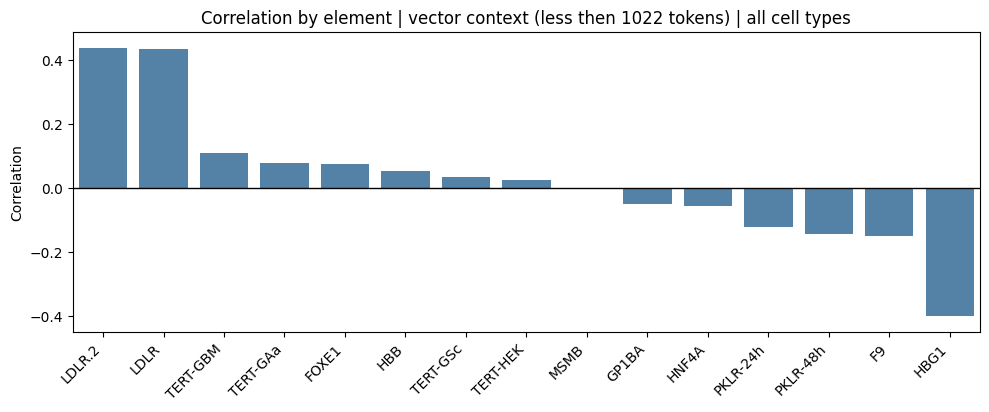

In [ ]:
#COPIED
plot_correlations(bench.corr)

**Benchmark object initialization**

In [13]:
bench = CAGI5_bench(model_cls='downstream_tasks.expression_prediction.expression_model_final.ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=100,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup,
            device='cuda:4')

**NO_OPTIM model validation**

In [ ]:
bench = CAGI5_bench(model_cls='downstream_tasks.expression_prediction.expression_model_final.ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=100,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup,
            device='cuda:4')

bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom',
                            context_fn=plasmid_context_NO_AUG,
                            padding_fn=genome_context,
                            min_tags=10)
bench.make_dataloader(batch_size=1, n_workers=8)
bench.initialize_model()
bench.run_inference()

In [6]:
bench = CAGI5_bench(model_cls='downstream_tasks.expression_prediction.expression_model_no_optim.ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=100,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup,
            device='cuda:4')

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:108: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

  0%|          | 0/567 [00:00<?, ?it/s]/home/jovyan/miniconda3/envs/cagi5/lib/python3.11/site-packages/torch/_inductor/compile_fx.py:150: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
100%|██████████| 567/567 [30:31<00:00,  3.23s/it]
/tmp/ipykernel_695505/2589648920.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | model with no optim validation, tags>10 | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.480601
 6       LDLR     0.465031
 3        HBB     0.381574
 13  TERT-GSc     0.212636
 11  TERT-GAa     0.197211
 12  TERT-GBM     0.173616
 5      HNF4A     0.169181
 14  TERT-HEK     0.084994
 10  PKLR-48h     0.082581
 9   PKLR-24h     0.058482
 1      FOXE1    -0.006586
 0         F9    -0.064528
 8       MSMB    -0.079662
 2      GP1BA    -0.184562
 4       HBG1    -0.317277)

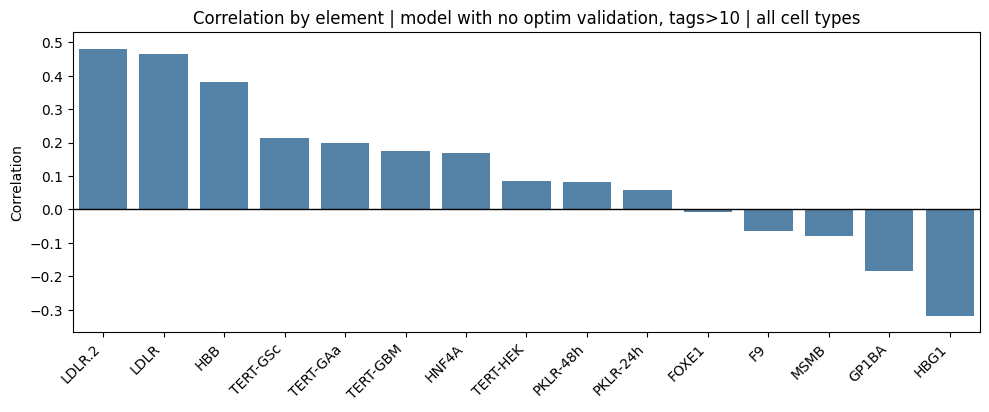

In [7]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom',
                            context_fn=plasmid_context_NO_AUG,
                            padding_fn=genome_context,
                            min_tags=10)
bench.make_dataloader(batch_size=30, n_workers=8)
bench.initialize_model()
bench.run_inference()
plot_correlations(bench.corr, title='Correlation by element | model with no optim validation, tags>10 | all cell types')

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:108: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

  0%|          | 0/567 [00:00<?, ?it/s]/home/jovyan/miniconda3/envs/cagi5/lib/python3.11/site-packages/torch/_inductor/compile_fx.py:150: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
100%|██████████| 567/567 [30:31<00:00,  3.23s/it]
/tmp/ipykernel_667734/2589648920.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | model with no optim validation, tags>10 | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.480601
 6       LDLR     0.465031
 3        HBB     0.381574
 13  TERT-GSc     0.212636
 11  TERT-GAa     0.197211
 12  TERT-GBM     0.173616
 5      HNF4A     0.169181
 14  TERT-HEK     0.084994
 10  PKLR-48h     0.082581
 9   PKLR-24h     0.058482
 1      FOXE1    -0.006586
 0         F9    -0.064528
 8       MSMB    -0.079662
 2      GP1BA    -0.184562
 4       HBG1    -0.317277)

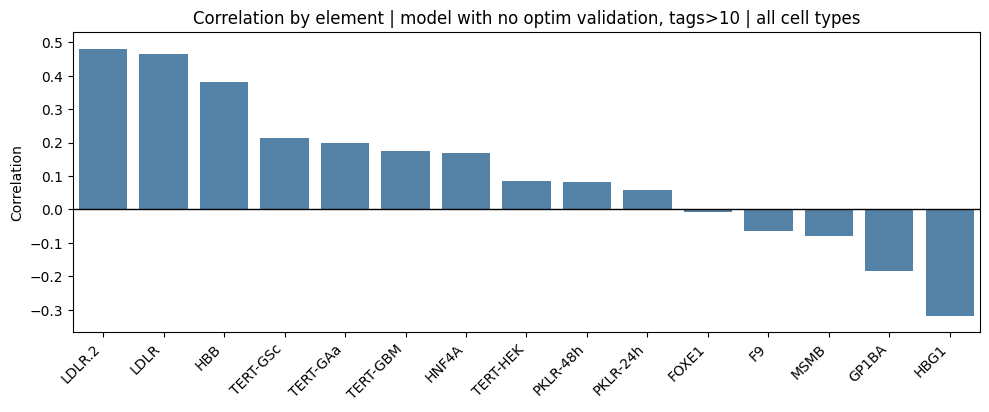

In [7]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom',
                            context_fn=plasmid_context_NO_AUG,
                            padding_fn=genome_context,
                            min_tags=10)
bench.make_dataloader(batch_size=30, n_workers=8)
bench.initialize_model()
bench.run_inference()
plot_correlations(bench.corr, title='Correlation by element | model with no optim validation, tags>10 | all cell types')

/tmp/ipykernel_413155/2589648920.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.505615
 6       LDLR     0.474121
 3        HBB     0.418579
 13  TERT-GSc     0.163330
 12  TERT-GBM     0.159668
 14  TERT-HEK     0.141174
 11  TERT-GAa     0.139282
 1      FOXE1     0.057556
 5      HNF4A     0.026016
 2      GP1BA     0.023163
 9   PKLR-24h    -0.008301
 10  PKLR-48h    -0.015854
 4       HBG1    -0.033539
 8       MSMB    -0.052628
 0         F9    -0.068848)

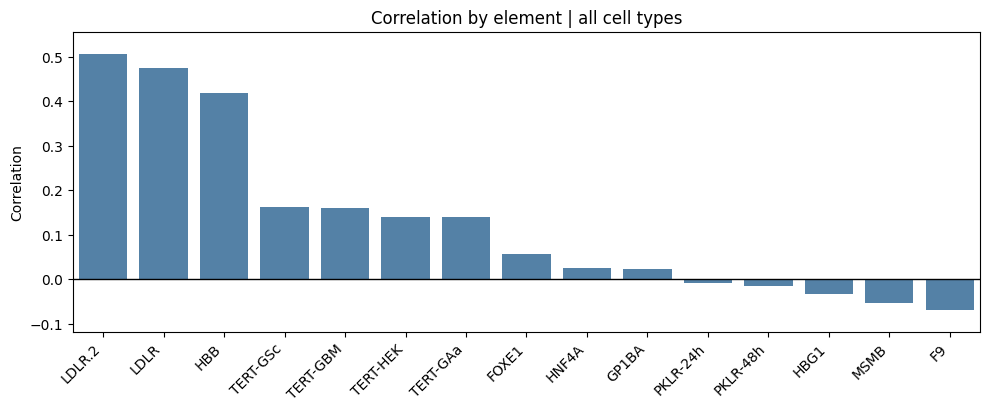

In [ ]:
plot_correlations(bench.corr, title='Correlation by element | model with no optim validation, tags>10 | all cell types')

In [ ]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom',
                            context_fn=plasmid_context_NO_AUG,
                            padding_fn=genome_context)
bench.make_dataloader(batch_size=1, n_workers=8)
bench.initialize_model()
bench.run_inference()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:108: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

100%|██████████| 616/616 [11:27<00:00,  1.12s/it]


/tmp/ipykernel_413155/2589648920.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | model with no optim validation, tags>10 | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.461182
 6       LDLR     0.433838
 3        HBB     0.231079
 12  TERT-GBM     0.129822
 13  TERT-GSc     0.060684
 1      FOXE1     0.051178
 11  TERT-GAa     0.048187
 9   PKLR-24h     0.043076
 5      HNF4A     0.040131
 10  PKLR-48h     0.018059
 14  TERT-HEK     0.017418
 2      GP1BA    -0.008572
 4       HBG1    -0.012039
 8       MSMB    -0.026436
 0         F9    -0.061905)

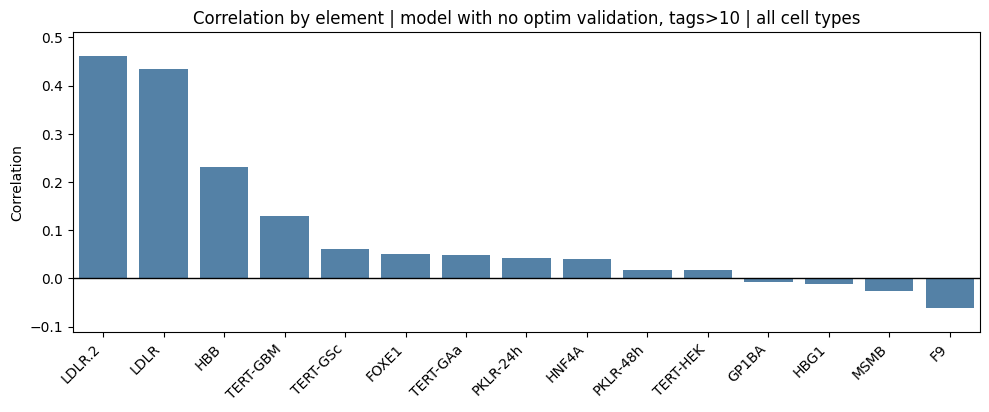

In [12]:
plot_correlations(bench.corr, title='Correlation by element | model with no optim validation, tags>10 | all cell types')

**Human genome safe harbor context**

In [ ]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom',
                            padding_fn=genome_context)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/tmp/ipykernel_2901925/3530143327.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | human safe harbor | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.278564
 6       LDLR     0.267456
 9   PKLR-24h     0.145386
 13  TERT-GSc     0.131653
 10  PKLR-48h     0.126343
 0         F9     0.114868
 11  TERT-GAa     0.093506
 12  TERT-GBM     0.082916
 5      HNF4A     0.045593
 14  TERT-HEK     0.036377
 8       MSMB    -0.001512
 1      FOXE1    -0.012501
 3        HBB    -0.053375
 4       HBG1    -0.053864
 2      GP1BA    -0.121368)

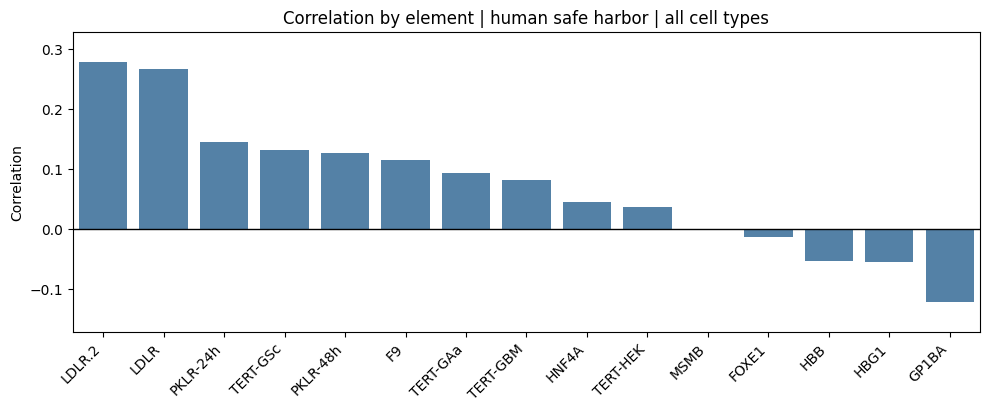

In [ ]:
#COPIED
plot_correlations(bench.corr)

**Plasmid context + safe harbor context**

In [14]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom',
                            context_fn=plasmid_context_NO_AUG,
                            padding_fn=genome_context,
                            min_tags=10)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:108: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

100%|██████████| 16983/16983 [39:07<00:00,  7.23it/s]


/tmp/ipykernel_413155/2589648920.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.506104
 6       LDLR     0.474487
 3        HBB     0.423828
 13  TERT-GSc     0.194580
 12  TERT-GBM     0.187988
 11  TERT-GAa     0.170166
 14  TERT-HEK     0.153503
 1      FOXE1     0.055664
 2      GP1BA     0.011627
 5      HNF4A    -0.005451
 9   PKLR-24h    -0.025803
 10  PKLR-48h    -0.034149
 8       MSMB    -0.046600
 0         F9    -0.061829
 4       HBG1    -0.079407)

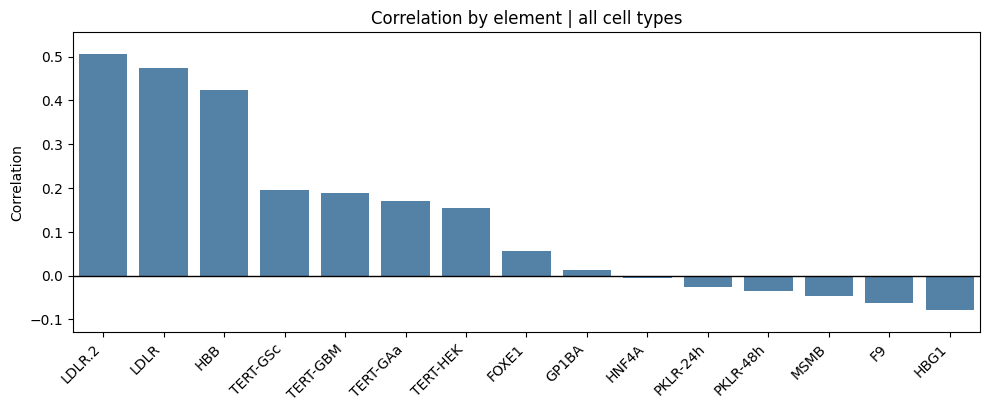

In [15]:
plot_correlations(bench.corr)

/tmp/ipykernel_3694385/2938281036.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | vector context + vector duplications | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.462280
 6       LDLR     0.433472
 3        HBB     0.231812
 12  TERT-GBM     0.163330
 11  TERT-GAa     0.092743
 13  TERT-GSc     0.091553
 14  TERT-HEK     0.051376
 1      FOXE1     0.043411
 9   PKLR-24h     0.036285
 5      HNF4A     0.027763
 10  PKLR-48h     0.009148
 8       MSMB    -0.022774
 2      GP1BA    -0.023750
 0         F9    -0.056122
 4       HBG1    -0.058395)

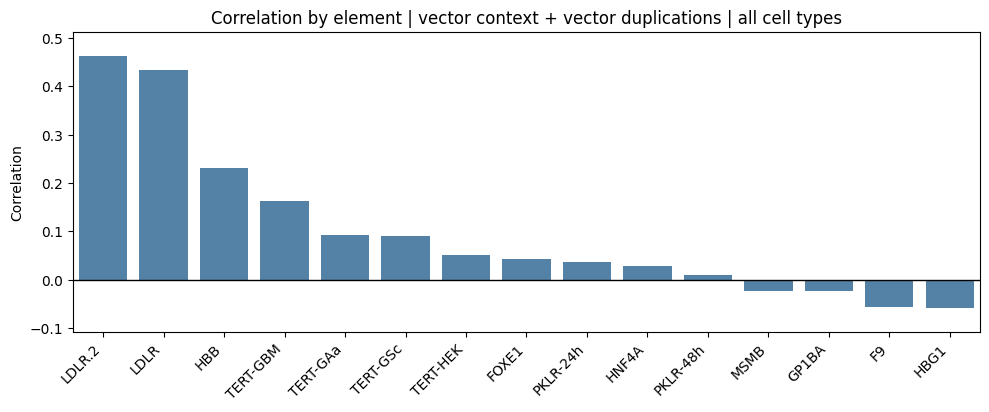

In [36]:
plot_correlations(bench.corr)

/tmp/ipykernel_3047605/2435687285.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | vector context + human safe harbor | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.462280
 6       LDLR     0.433472
 3        HBB     0.231812
 12  TERT-GBM     0.163330
 11  TERT-GAa     0.092743
 13  TERT-GSc     0.091553
 14  TERT-HEK     0.051376
 1      FOXE1     0.043411
 9   PKLR-24h     0.036285
 5      HNF4A     0.027763
 10  PKLR-48h     0.009148
 8       MSMB    -0.022774
 2      GP1BA    -0.023750
 0         F9    -0.056122
 4       HBG1    -0.058395)

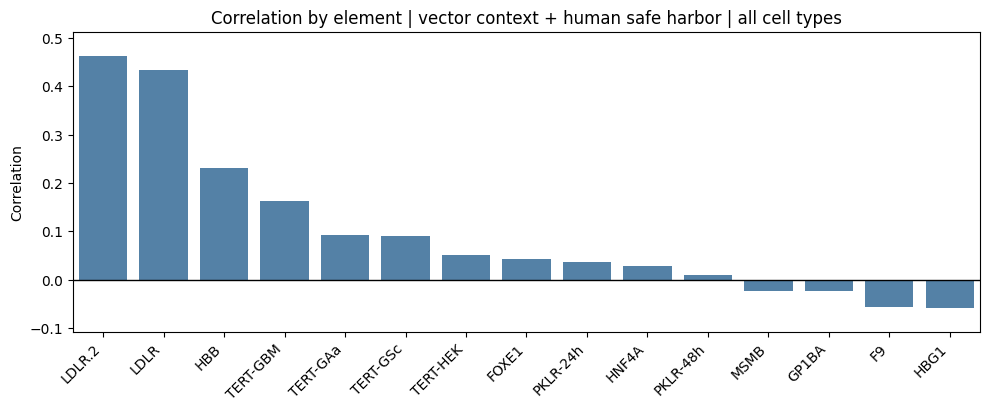

In [ ]:
#COPIED
plot_correlations(bench.corr)

**Plasmid context + plasmid duplicaitons**

In [ ]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom', 
                            context_fn=plasmid_context_AUG)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/tmp/ipykernel_3047605/2938281036.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | vector context + vector duplications | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.436768
 6       LDLR     0.415405
 4       HBG1     0.097290
 3        HBB     0.054855
 0         F9     0.054413
 1      FOXE1     0.041687
 8       MSMB     0.018837
 2      GP1BA    -0.030266
 14  TERT-HEK    -0.055664
 12  TERT-GBM    -0.063293
 5      HNF4A    -0.070068
 10  PKLR-48h    -0.072113
 11  TERT-GAa    -0.072601
 13  TERT-GSc    -0.092163
 9   PKLR-24h    -0.097961)

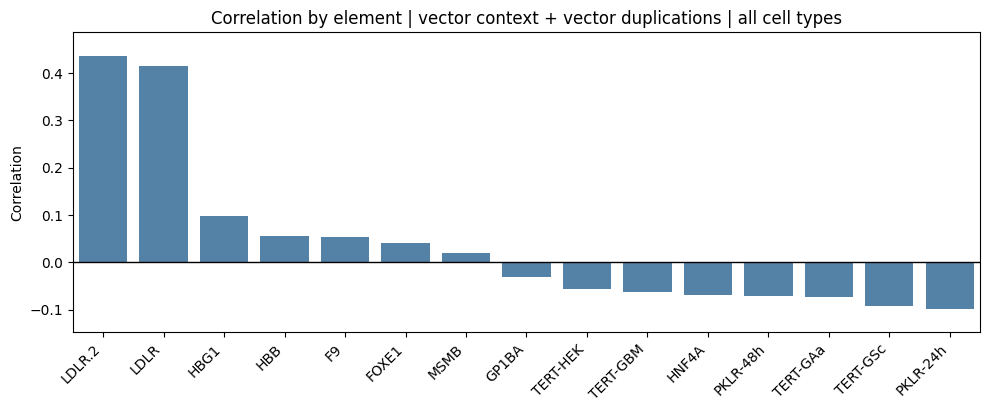

In [ ]:
#COPIED
plot_correlations(bench.corr)

**MPRA fragments in local genome context**

In [ ]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='default', 
                            length=20000)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/tmp/ipykernel_3143629/4158300190.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | mpra element in local genomic context | all cell types'}, ylabel='Correlation'>,
         name  correlation
 11  TERT-GAa     0.123718
 12  TERT-GBM     0.114624
 13  TERT-GSc     0.099731
 3        HBB     0.086884
 5      HNF4A     0.074341
 14  TERT-HEK     0.039398
 1      FOXE1     0.011143
 9   PKLR-24h     0.003889
 10  PKLR-48h    -0.001287
 0         F9    -0.010895
 8       MSMB    -0.014511
 7     LDLR.2    -0.025314
 6       LDLR    -0.042679
 4       HBG1    -0.120209
 2      GP1BA    -0.136536)

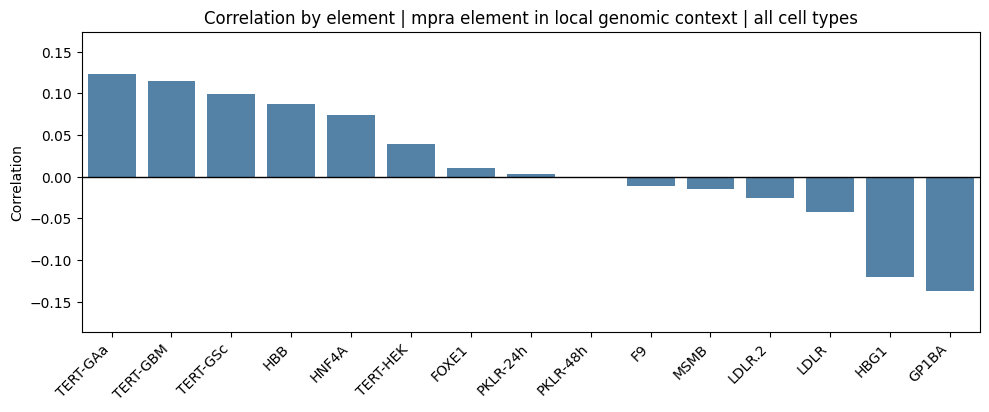

In [ ]:
#COPIED
plot_correlations(bench.corr)

**MPRA fragment only (no context)**

In [9]:
bench = CAGI5_bench(model_cls='downstream_tasks.expression_prediction.expression_model_final.ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=100,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup,
            device='cuda:2')

In [10]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom', min_tags=10)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:108: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

100%|██████████| 16983/16983 [38:46<00:00,  7.30it/s]


In [12]:
bench.corr

{'F9': tensor([[1.0000, 0.1184],
         [0.1185, 1.0000]], device='cuda:2', dtype=torch.float16),
 'FOXE1': tensor([[0.9995, 0.0278],
         [0.0278, 1.0000]], device='cuda:2', dtype=torch.float16),
 'GP1BA': tensor([[ 1.0000, -0.0914],
         [-0.0914,  0.9995]], device='cuda:2', dtype=torch.float16),
 'HBB': tensor([[ 1.0000, -0.0275],
         [-0.0276,  0.9990]], device='cuda:2', dtype=torch.float16),
 'HBG1': tensor([[ 1.0000, -0.2438],
         [-0.2439,  1.0000]], device='cuda:2', dtype=torch.float16),
 'HNF4A': tensor([[0.9995, 0.0293],
         [0.0293, 1.0000]], device='cuda:2', dtype=torch.float16),
 'LDLR': tensor([[1.0000, 0.4524],
         [0.4524, 1.0000]], device='cuda:2', dtype=torch.float16),
 'LDLR.2': tensor([[1.0000, 0.4587],
         [0.4587, 1.0000]], device='cuda:2', dtype=torch.float16),
 'MSMB': tensor([[1.0000, 0.0188],
         [0.0188, 1.0000]], device='cuda:2', dtype=torch.float16),
 'PKLR-24h': tensor([[0.9995, 0.1481],
         [0.1481, 1.0000]], d

In [ ]:
0.118439,0.027786,-0.091400,-0.027550,-0.243835,0.029335,0.452393,0.458740,0.018814,0.148071,0.119476,0.467529,0.508301,0.500000,0.404541

/tmp/ipykernel_904157/2589648920.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | MPRA fragments without context, no filtration | all cell types'}, ylabel='Correlation'>,
         name  correlation
 12  TERT-GBM     0.508301
 13  TERT-GSc     0.500000
 11  TERT-GAa     0.467529
 7     LDLR.2     0.458740
 6       LDLR     0.452393
 14  TERT-HEK     0.404541
 9   PKLR-24h     0.148071
 10  PKLR-48h     0.119476
 0         F9     0.118439
 5      HNF4A     0.029335
 1      FOXE1     0.027786
 8       MSMB     0.018814
 3        HBB    -0.027550
 2      GP1BA    -0.091400
 4       HBG1    -0.243835)

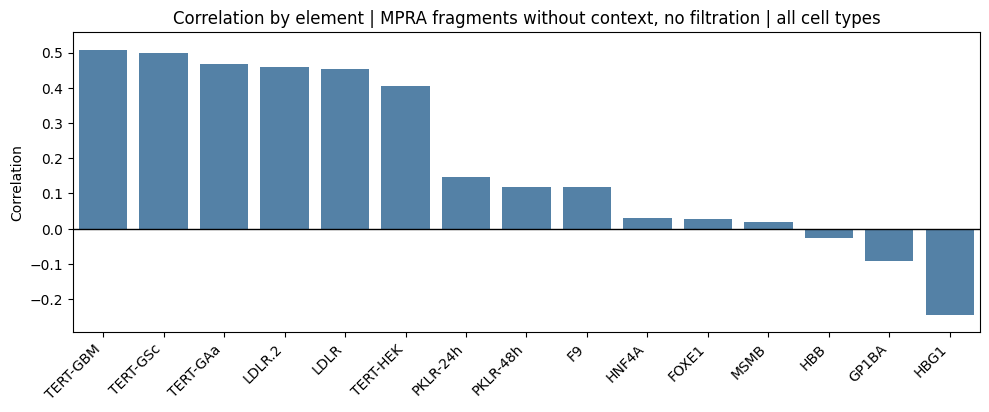

In [11]:
plot_correlations(bench.corr, title='Correlation by element | MPRA fragments without context, no filtration | all cell types')

In [41]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom')
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:107: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

  0%|          | 0/18468 [00:00<?, ?it/s]Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 26 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
Upstream too short: 25 < 511
  0%|          | 1/18468 [00:11<57:33:59, 11.22s/it]Upstream too short: 25 < 511
Upstream too short: 26 < 511
  0%|          | 2/18468 [00:11<24:07:22,  4.70s/it]Upstream too short: 25 < 511
Upstream too short: 25 < 511
  0%|          | 3/18468 [00:11<13:25:50,  2.62s/it]Upstream too short: 25 < 511
Upstream too short: 

/tmp/ipykernel_3754028/2589648920.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | MPRA fragments without context, no filtration | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.419434
 6       LDLR     0.407471
 12  TERT-GBM     0.376953
 13  TERT-GSc     0.342163
 11  TERT-GAa     0.328979
 14  TERT-HEK     0.212769
 10  PKLR-48h     0.125488
 0         F9     0.124329
 9   PKLR-24h     0.097382
 1      FOXE1     0.016174
 5      HNF4A     0.009842
 8       MSMB    -0.003713
 3        HBB    -0.023071
 2      GP1BA    -0.092590
 4       HBG1    -0.226257)

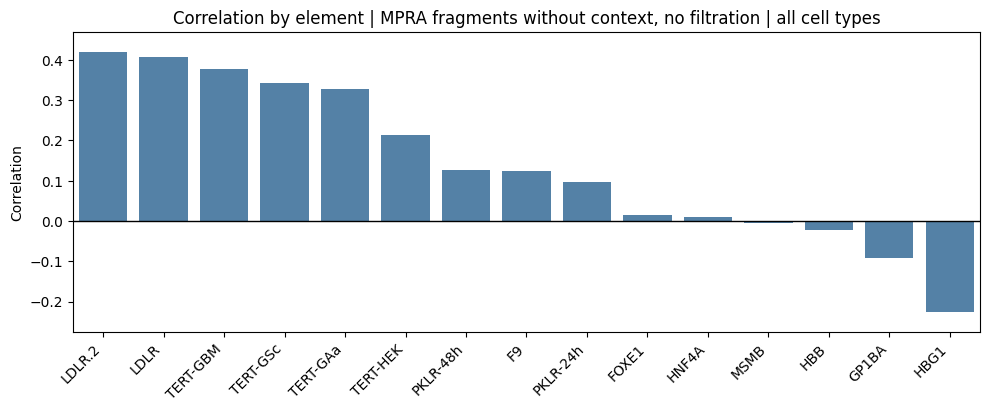

In [42]:
plot_correlations(bench.corr, title='Correlation by element | MPRA fragments without context, no filtration | all cell types')

/tmp/ipykernel_3754028/2589648920.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | MPRA fragments without context | all cell types'}, ylabel='Correlation'>,
         name  correlation
 12  TERT-GBM     0.572266
 13  TERT-GSc     0.564941
 11  TERT-GAa     0.530762
 14  TERT-HEK     0.495361
 7     LDLR.2     0.473511
 6       LDLR     0.469727
 9   PKLR-24h     0.209229
 0         F9     0.164001
 10  PKLR-48h     0.143799
 1      FOXE1     0.087860
 5      HNF4A     0.041702
 8       MSMB     0.034546
 3        HBB    -0.009560
 2      GP1BA    -0.115204
 4       HBG1    -0.278076)

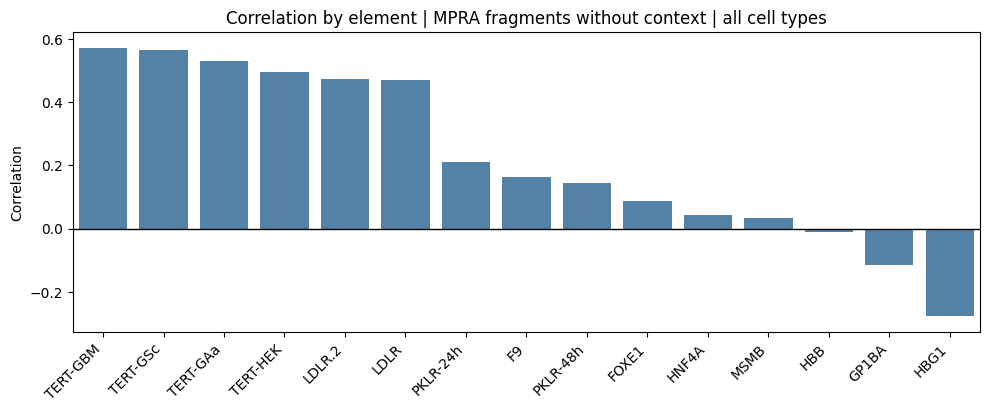

In [40]:
plot_correlations(bench.corr, title='Correlation by element | MPRA fragments without context | all cell types')

In [7]:
bench.initialize_dataset(elements=['HBG1'], 
                            mode='custom',
                            min_tags=10,
                            max_pvalue=0.1)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:107: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

  0%|          | 0/456 [00:00<?, ?it/s]Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Upstream too short: 22 < 511
Casting fp32 inputs back to torch.float16 for flash-attn compatibility.
  0%|          | 1/456 [00:13<1:45:36, 13.93s/it]Upstream too short: 22 < 511
Upstream too short: 22 < 511
  0%|          | 2/456 [00:14<44:03,  5.82s/it]  Upstream too short: 22 < 511
Upstream too short: 22 < 511
  1%|          | 3/456 [00:14<24:22, 

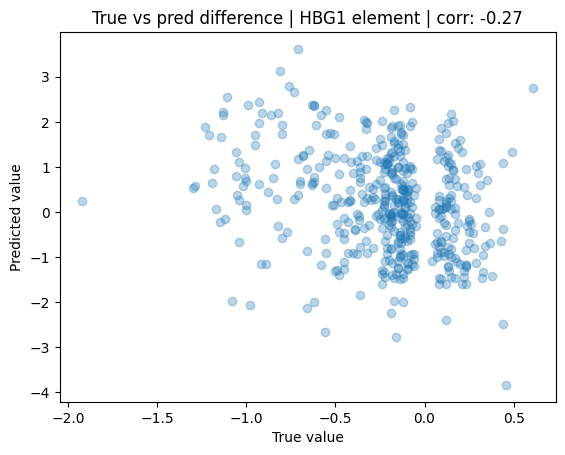

In [8]:
for key in bench.corr:
    corr = bench.corr[key][0][1].item()
    plt.scatter(x=bench.true_vs_pred[key][:, 0].cpu(), y = bench.true_vs_pred[key][:, 1].cpu(), alpha=0.3)
    plt.xlabel('True value')
    plt.ylabel('Predicted value')
    plt.title(f'True vs pred difference | {key} element | corr: {round(corr, 2)}')
    plt.show()
    plt.close()

In [2]:
for key in bench.corr:
    corr = bench.corr[key][0][1].item()
    plt.scatter(x=bench.true_vs_pred[key][:, 0].cpu(), y = bench.true_vs_pred[key][:, 1].cpu(), alpha=0.3)
    plt.xlabel('True value')
    plt.ylabel('Predicted value')
    plt.title(f'True vs pred difference | {key} element | corr: {round(corr, 2)}')
    plt.show()
    plt.close()

NameError: name 'bench' is not defined